<a href="https://colab.research.google.com/github/VasilievNichita/IA_LABS/blob/main/Lab_3_IA_Vasiliev_Nichita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

In [ ]:
url = "https://raw.githubusercontent.com/llimllib/bostonmarathon/master/results/2014/results.csv"

df = pd.read_csv(url)

df.head()

,10k,name,division,25k,gender,age,official,bib,genderdiv,ctz,...,overall,pace,state,30k,5k,half,20k,country,city,40k
0,17.37,"Yamamoto, Hiroyuki",8,47.67,M,47,85.25,W1,8,NaN,...,8,3.27,NaN,59.18,8.02,39.72,37.65,JPN,Fukuoka,80.43
1,32.58,"Jeptoo, Rita",1,82.43,F,33,138.95,F1,1,NaN,...,21,5.30,NaN,99.33,16.22,69.47,65.83,KEN,Eldoret,132.10
2,16.62,"Van Dyk, Ernst F.",1,45.80,M,41,80.60,W2,1,NaN,...,1,3.08,NaN,56.45,7.75,38.03,36.10,RSA,Paarl,76.10
3,32.57,"Dibaba, Mare",3,82.43,F,24,140.58,F2,3,NaN,...,27,5.37,NaN,99.33,16.20,69.47,65.83,ETH,Shoa,132.95
4,17.12,"Hokinoue, Kota",2,46.37,M,40,81.23,W3,2,NaN,...,2,3.10,NaN,57.03,8.02,38.60,36.58,JPN,Nogata Fukuoka,76.72


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31984 entries, 0 to 31983
Data columns (total 21 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   10k        31984 non-null  object 
 1   name       31984 non-null  object 
 2   division   31984 non-null  int64  
 3   25k        31984 non-null  object 
 4   gender     31984 non-null  object 
 5   age        31984 non-null  int64  
 6   official   31984 non-null  float64
 7   bib        31984 non-null  object 
 8   genderdiv  31984 non-null  int64  
 9   ctz        1244 non-null   object 
 10  35k        31984 non-null  object 
 11  overall    31984 non-null  int64  
 12  pace       31984 non-null  float64
 13  state      29408 non-null  object 
 14  30k        31984 non-null  object 
 15  5k         31984 non-null  object 
 16  half       31984 non-null  object 
 17  20k        31984 non-null  object 
 18  country    31984 non-null  object 
 19  city       31983 non-null  object 
 20  40k   

In [ ]:
data = df[['age','overall','pace']]

data = data.dropna()

data.head()

,age,overall,pace
0,47,8,3.27
1,33,21,5.30
2,41,1,3.08
3,24,27,5.37
4,40,2,3.10


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(data)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

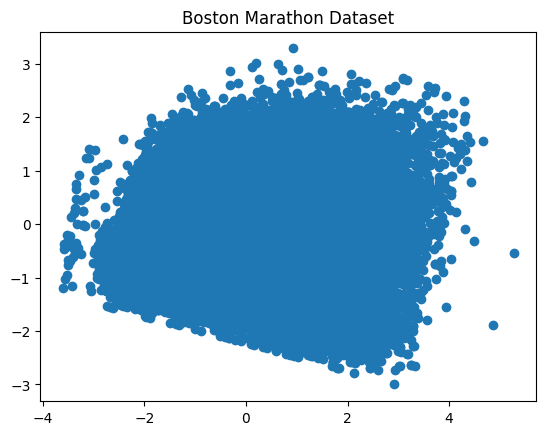

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("Boston Marathon Dataset")
plt.show()

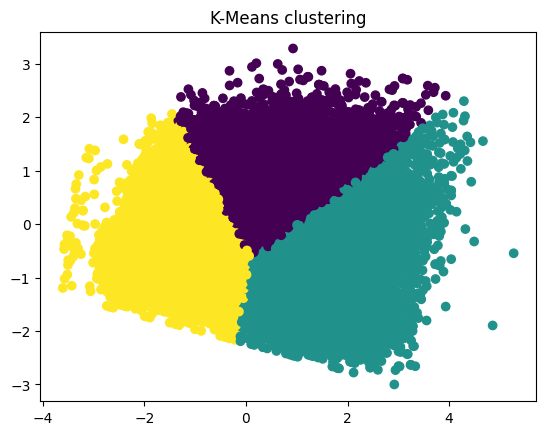

Silhouette score (K-Means): 0.3764408906555418


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)

labels_kmeans = kmeans.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_kmeans)
plt.title("K-Means clustering")
plt.show()

score_kmeans = silhouette_score(X, labels_kmeans)

print("Silhouette score (K-Means):", score_kmeans)

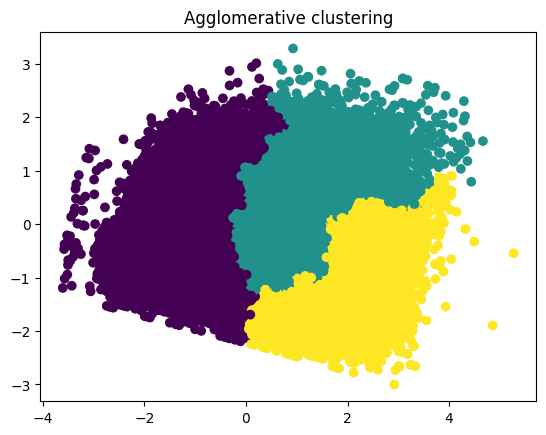

Silhouette score (Agglomerative): 0.3441419859643434


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3)

labels_agg = agg.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_agg)
plt.title("Agglomerative clustering")
plt.show()

score_agg = silhouette_score(X, labels_agg)

print("Silhouette score (Agglomerative):", score_agg)

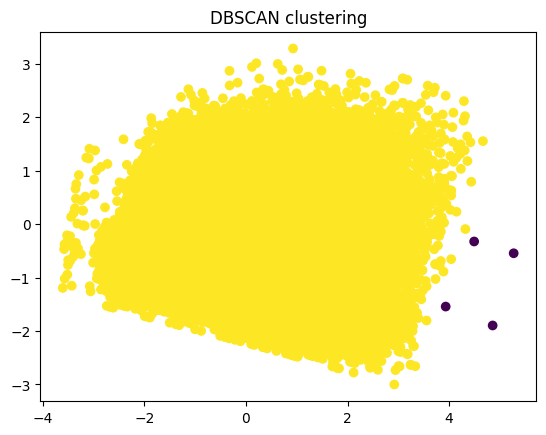

Silhouette score (DBSCAN): 0.5697320106195048


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

labels_db = dbscan.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_db)
plt.title("DBSCAN clustering")
plt.show()

score_db = silhouette_score(X, labels_db)

print("Silhouette score (DBSCAN):", score_db)

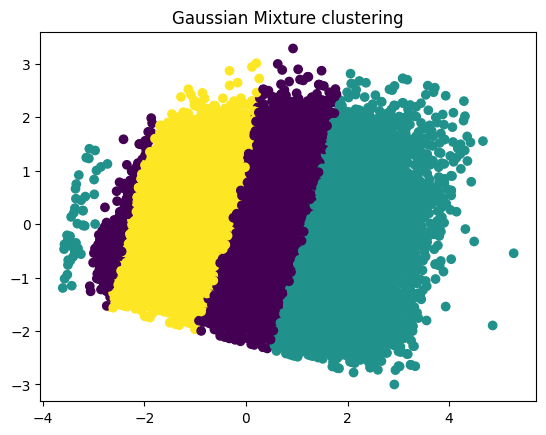

Silhouette score (Gaussian Mixture): 0.280039188389993


In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)

labels_gmm = gmm.fit_predict(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_gmm)
plt.title("Gaussian Mixture clustering")
plt.show()

score_gmm = silhouette_score(X, labels_gmm)

print("Silhouette score (Gaussian Mixture):", score_gmm)

In [ ]:
results = pd.DataFrame({
    "Algorithm": ["K-Means", "Agglomerative", "DBSCAN", "Gaussian Mixture"],
    "Silhouette Score": [score_kmeans, score_agg, score_db, score_gmm]
})

print(results)

          Algorithm  Silhouette Score
0           K-Means          0.376441
1     Agglomerative          0.344142
2            DBSCAN          0.569732
3  Gaussian Mixture          0.280039


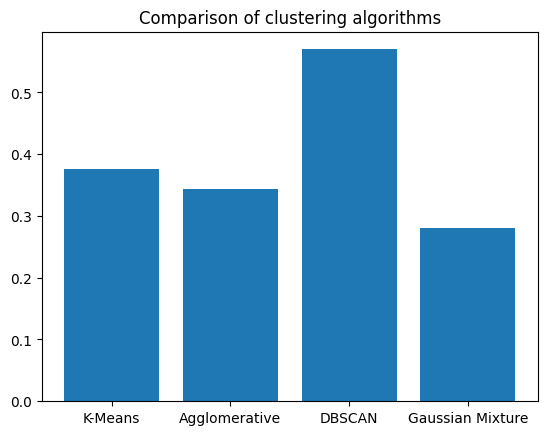

In [ ]:
plt.bar(results["Algorithm"], results["Silhouette Score"])

plt.title("Comparison of clustering algorithms")

plt.show()